# Assignment

## Data Preparation

### **Fixed Sequence Length (C = 30)**

After trimming, all sequences still had different lengths depending on the leght of the squat. Instead of using zero padding, every sequence was converted into a fixed sequence length of C = 30 frames by selecting equally spaced frames across the entire movement. This ensured that all videos had the same dimension while still preserving information from the full squat motion. Sequences shorter than 30 frames were excluded from the dataset.


### **Features**

For every selected frame, MediaPipe pose landmarks were used to extract:

* Head
* Left/right shoulder
* Left/right elbow
* Left/right hand
* Left/right hip
* Left/right knee
* Left/right foot

For each joint, the following features were stored:

* x-coordinate
* y-coordinate
* z-coordinate

This resulted in: $\quad 13 \text{ joints} \times 3 \text{ features} = 39 \text{ features per frame}$

After converting each sequence to $30$ frames: $\quad 30 \text{ frames} \times 39 \text{ features}$

Each video sequence was finally flattened into one row in a CSV file.


### **Target**

The target values were loaded from a separate CSV file containing:

* video filename
* exercise score

The original scores were scaled into the interval $0-4$ using MinMax scaling. Videos marked as not squat were manually removed before scaling to avoid affecting the score distribution.

## RNN models

We test the performance of different RNN models, one simple, one LSTM and one GRU.

### Data Prep

In [34]:
import numpy as np
import os
import json
import torch
from torchinfo import summary
import data_functions as dfunc

folder_path = "../../MainProject/data/mediapipe_trimmed_world"
score_path = "../../MainProject/data/video_scores.csv"

device = torch.device("cpu")

random_state = 42

train_data, test_data, train_y, test_y = dfunc.load_folder_with_split(
    folder_path=folder_path,
    target_path=score_path,
    test_size=0.2,
    random_state=random_state,
    select_rows=True,
    num_rows=30)

X_test = dfunc.augument_data(test_data, mirror_axis=[[False, False, False]], rotations=[0])
Y_test = torch.tensor(test_y, dtype=torch.float32).reshape(-1, 1)

In [35]:
RNN_folder_path = "scoring_models/RNN_models"

RNNcheckpoint = torch.load(os.path.join(RNN_folder_path, "SimpleRNNModel_scoring_checkpoint.pth"), weights_only=False)
LSTMcheckpoint = torch.load(os.path.join(RNN_folder_path, "LSTMModel_scoring_checkpoint.pth"), weights_only=False)
GRUcheckpoint = torch.load(os.path.join(RNN_folder_path, "GRUModel_scoring_checkpoint.pth"), weights_only=False)

RNN_checkpoints = [RNNcheckpoint, LSTMcheckpoint, GRUcheckpoint]

RNN_models = []
for checkpoint in RNN_checkpoints:
    model = checkpoint["model_config"]["model_type"](
        checkpoint["model_config"]["input_size"],
        checkpoint["model_config"]["hidden_size"],
        checkpoint["model_config"]["depth"],
        checkpoint["model_config"]["num_of_classification_labels"],
    ).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    RNN_models.append(model)

for i, model in enumerate(RNN_models):
    if model is not None:
        print(f"{model.to_string()} successfully loaded!")
        print(f"Parameters:")
        for parameter, value in RNN_checkpoints[i]["model_config"].items():
            print(f"\t{parameter}: {value}")
        print()

SimpleRNNModel successfully loaded!
Parameters:
	model_type: <class 'RNN_models.SimpleRNNModel'>
	classifier: False
	input_size: 39
	hidden_size: 32
	depth: 5
	num_of_classification_labels: 1
	lr: 0.0001
	loss_func: <class 'torch.nn.modules.loss.MSELoss'>
	optimizer: <class 'torch.optim.adam.Adam'>
	batch_size: 256
	patience: 3
	epochs: 100

LSTMModel successfully loaded!
Parameters:
	model_type: <class 'RNN_models.LSTMModel'>
	classifier: False
	input_size: 39
	hidden_size: 32
	depth: 5
	num_of_classification_labels: 1
	lr: 0.0001
	loss_func: <class 'torch.nn.modules.loss.MSELoss'>
	optimizer: <class 'torch.optim.adam.Adam'>
	batch_size: 256
	patience: 3
	epochs: 100

GRUModel successfully loaded!
Parameters:
	model_type: <class 'RNN_models.GRUModel'>
	classifier: False
	input_size: 39
	hidden_size: 32
	depth: 5
	num_of_classification_labels: 1
	lr: 0.0001
	loss_func: <class 'torch.nn.modules.loss.MSELoss'>
	optimizer: <class 'torch.optim.adam.Adam'>
	batch_size: 256
	patience: 3
	epo

## Evaluation

Looking at the accrued data we see that the models are somewhat good at predicting scores, although it might look like the scoring is all over the place.

- **Simple:**
The simple model, being the cheapest parameter-wise with roughly 10'000 parameters, is also the "worst" of the three RNN's. With a somewhat significant overestimation of scoring it is adviced to take the decisions with a grain of salt.

- **LSTM:**
I had high hopes for the LSTM, looking at it's past performances, I suspected it would perform just as well this time, but alas, it did not, rvrn with roughly 40'000 parameters. Looking at the actual vs predicted graph, we can see some sort of step-function starting to take form, althought this could simply be from the random seed we decided to use (42, I haven't tested others). Excluding the extreme residuals we seem to have a decent range of $\pm1$ (quite bad).

- **GRU**
Now for the GRU, with roughly 30'000 parameters, which I also had high hopes for, for the same reasons as for the LSTM. Quite similarily to the simple model, the GRU also has a signinficant chance to overestimate the squat and give a higher than deserved score.


Model: SimpleRNNModel
MSE:  0.4803
RMSE: 0.6931
MAE:  0.5145
R²:   0.4219


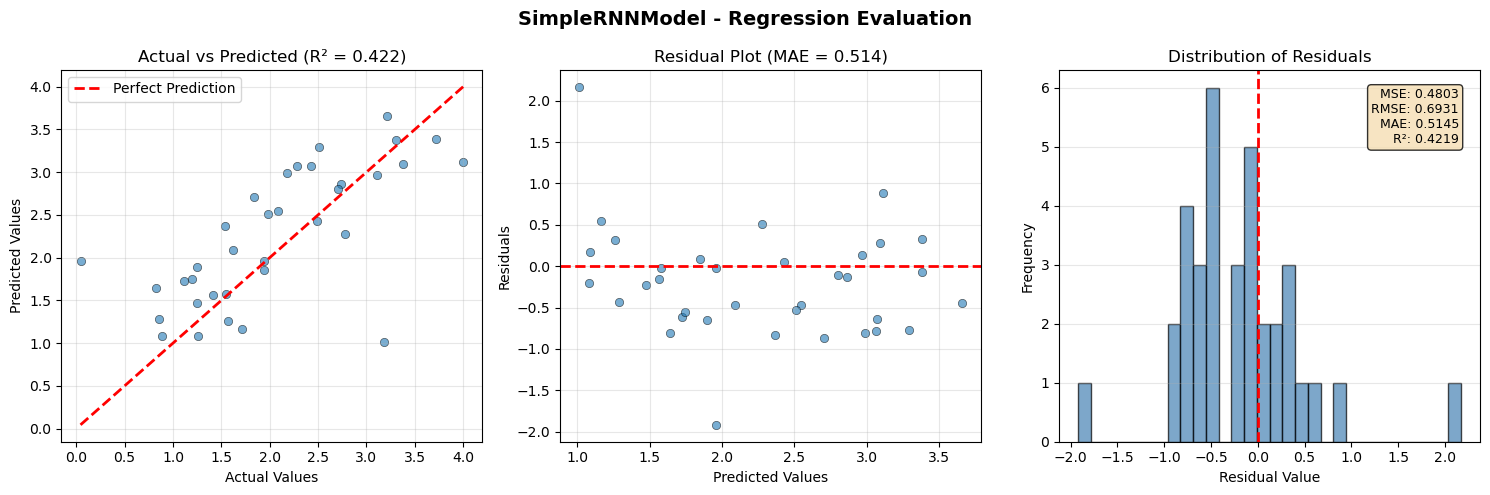


Model: LSTMModel
MSE:  0.3289
RMSE: 0.5735
MAE:  0.4587
R²:   0.6042


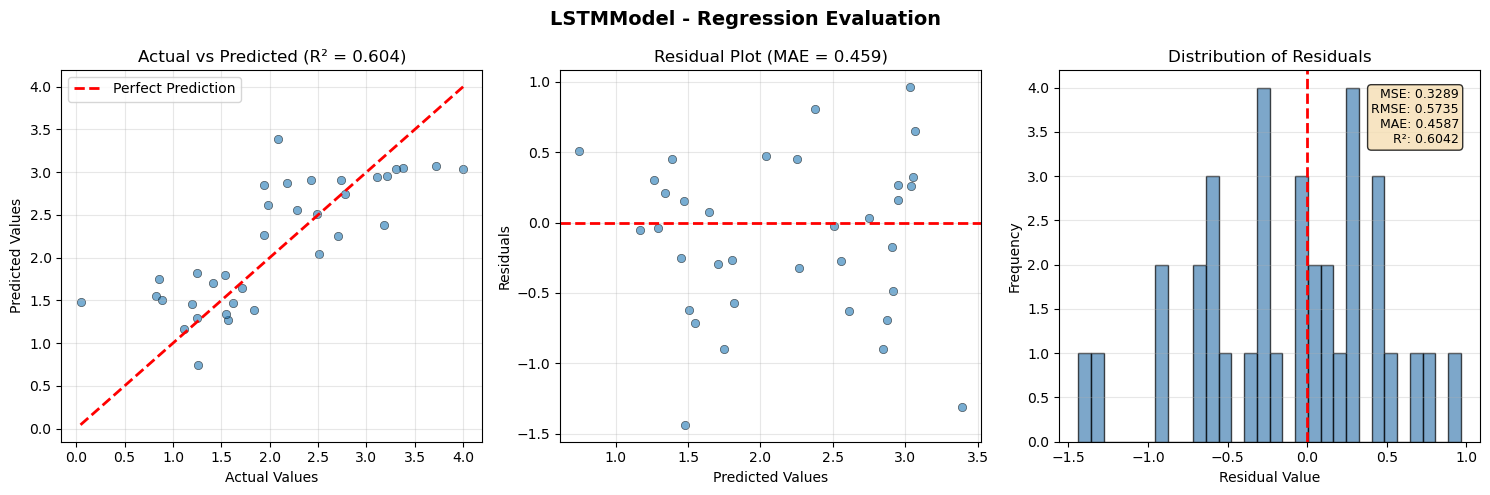


Model: GRUModel
MSE:  0.3898
RMSE: 0.6244
MAE:  0.4376
R²:   0.5308


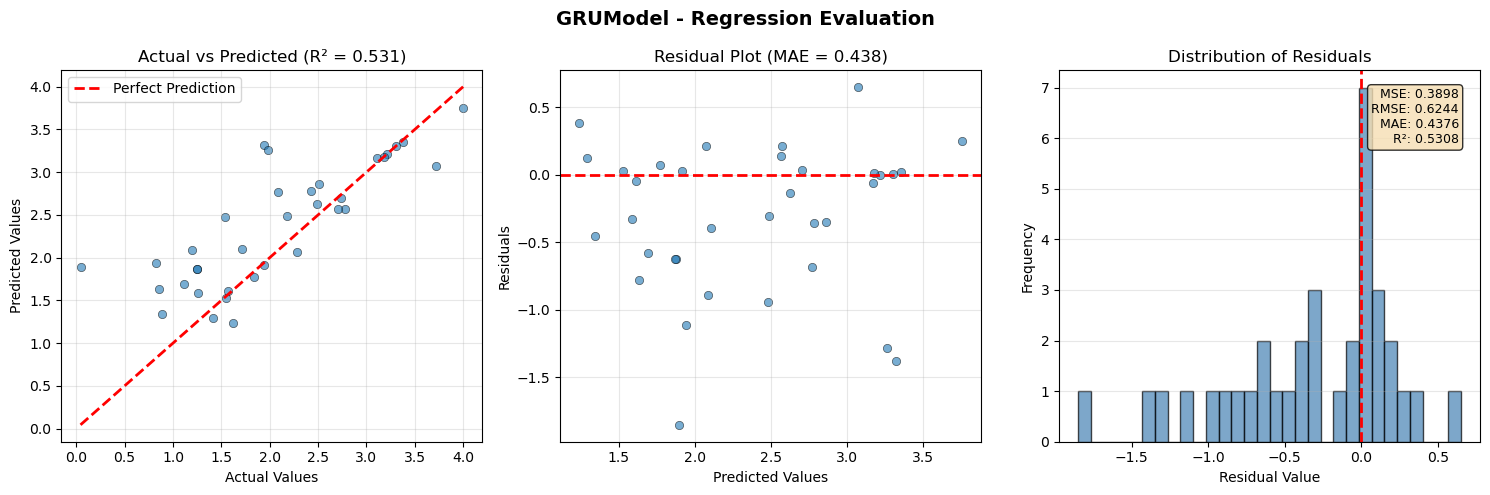

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

for i, model in enumerate(RNN_models):
    model.eval()
    with torch.no_grad():
        X_test_tensor = torch.as_tensor(X_test, dtype=torch.float32, device=device)
        predictions = model(X_test_tensor).cpu().numpy()
        
        # Calculate metrics
        mse = mean_squared_error(Y_test, predictions)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(Y_test, predictions)
        r2 = r2_score(Y_test, predictions)
        
        # Print metrics
        print(f"\n{'='*50}")
        print(f"Model: {RNN_models[i].to_string()}")
        print(f"{'='*50}")
        print(f"MSE:  {mse:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"MAE:  {mae:.4f}")
        print(f"R²:   {r2:.4f}")
        
        # Create visualization
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig.suptitle(f"{RNN_models[i].to_string() if hasattr(RNN_models[i], 'to_string') else type(model).__name__} - Regression Evaluation", 
                     fontsize=14, fontweight='bold')
        
        # Plot 1: Actual vs Predicted
        axes[0].scatter(Y_test, predictions, alpha=0.6, edgecolors='k', linewidth=0.5)
        axes[0].plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2, label='Perfect Prediction')
        axes[0].set_xlabel('Actual Values')
        axes[0].set_ylabel('Predicted Values')
        axes[0].set_title(f'Actual vs Predicted (R² = {r2:.3f})')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Plot 2: Residuals
        residuals = Y_test - predictions
        axes[1].scatter(predictions, residuals, alpha=0.6, edgecolors='k', linewidth=0.5)
        axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
        axes[1].set_xlabel('Predicted Values')
        axes[1].set_ylabel('Residuals')
        axes[1].set_title(f'Residual Plot (MAE = {mae:.3f})')
        axes[1].grid(True, alpha=0.3)
        
        # Plot 3: Distribution of errors
        axes[2].hist(residuals, bins=30, alpha=0.7, edgecolor='black', color='steelblue')
        axes[2].axvline(x=0, color='r', linestyle='--', lw=2)
        axes[2].set_xlabel('Residual Value')
        axes[2].set_ylabel('Frequency')
        axes[2].set_title('Distribution of Residuals')
        axes[2].grid(True, alpha=0.3, axis='y')
        
        # Add text box with metrics
        metrics_text = f'MSE: {mse:.4f}\nRMSE: {rmse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}'
        axes[2].text(0.95, 0.95, metrics_text, transform=axes[2].transAxes,
                    fontsize=9, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        plt.tight_layout()
        plt.show()

# CNN

In [37]:
from CNN_model import *

input_shape = (30, 39)

champion_dir = "scoring_models/CNN_models"
metadata_dir = "scoring_models/CNN_models"


model_path = os.path.join(champion_dir, "champion_model.pt")
info_path = os.path.join(metadata_dir, "champion_info.json")

state_dict = torch.load(model_path, map_location=device)

with open(info_path, "r") as f:
    champion_info = json.load(f)

best_config = champion_info["hyperparameters"]

print(f"Champion model configuration: {best_config}\n")

# Rebuild model
model = build_cnn_model(best_config, input_shape)
model.load_state_dict(state_dict)
model.to(device) 


# Summarize model
model_summary = summary(model, input_size=(1, 1, input_shape[0], input_shape[1]))

print(model_summary)

Champion model configuration: {'lr': 0.005, 'dropout': 0.25, 'epochs': 250, 'weight_decay': 0.0001}

Layer (type:depth-idx)                   Output Shape              Param #
SquatClassifierCNN                       [1, 1]                    --
├─Sequential: 1-1                        [1, 32, 15, 19]           --
│    └─Conv2d: 2-1                       [1, 32, 30, 39]           320
│    └─BatchNorm2d: 2-2                  [1, 32, 30, 39]           64
│    └─ReLU: 2-3                         [1, 32, 30, 39]           --
│    └─MaxPool2d: 2-4                    [1, 32, 15, 19]           --
│    └─Dropout2d: 2-5                    [1, 32, 15, 19]           --
├─Sequential: 1-2                        [1, 64, 7, 9]             --
│    └─Conv2d: 2-6                       [1, 64, 15, 19]           18,496
│    └─BatchNorm2d: 2-7                  [1, 64, 15, 19]           128
│    └─ReLU: 2-8                         [1, 64, 15, 19]           --
│    └─MaxPool2d: 2-9                    [1, 64,

# data loading

In [38]:
import data_function_CNN as data_cnn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
data_dir = "../Data/mediapipe_score_fixed_c"

X, y = data_cnn.load_and_reshape_all_files(data_dir, n_frames=30, n_features=39)
print(f"Original samples: {X.shape[0]}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply mirror augmentation
print("Applying mirror augmentation...")
X_train_mirrored = data_cnn.mirror_pose_data(X_train)
y_train_mirrored = y_train.copy()

# Concatenate original and mirrored
X_train_augmented = np.concatenate([X_train, X_train_mirrored], axis=0)
y_train_augmented = np.concatenate([y_train, y_train_mirrored], axis=0)

# Add noise augmentation
X_noisy = data_cnn.augment_with_noise(X_train_augmented)

X_train_final = np.concatenate([X_train_augmented, X_noisy], axis=0)
y_train_final = np.concatenate([y_train_augmented, y_train_augmented], axis=0)

print(f"Final training samples: {X_train_final.shape[0]}")

# Standardize features
scaler = StandardScaler()
X_train_flat = X_train_final.reshape(-1, X_train_final.shape[-1])
X_test_flat = X_test.reshape(-1, X_test.shape[-1])

X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)

# Reshape back
X_train = X_train_flat.reshape(X_train_final.shape)
X_test = X_test_flat.reshape(X_test.shape)

# Add channel dimension for CNN (batch, channels, frames, features)
X_train = X_train[:, np.newaxis, :, :]
X_test = X_test[:, np.newaxis, :, :]

y_train = y_train_final
y_test = y_test

# Ensure data is contiguous after all operations
X_train = np.ascontiguousarray(X_train)
X_test = np.ascontiguousarray(X_test)
Y_train = np.ascontiguousarray(y_train)
Y_test = np.ascontiguousarray(y_test)

# CRITICAL: Correct order - (frames, features)
input_shape = (30, 39)  # 30 frames, 39 features

print(f"Final X_train shape: {X_train.shape}")  # Should be (N, 1, 30, 39)
print(f"Final X_test shape: {X_test.shape}")    # Should be (N, 1, 30, 39)
print(f"input_shape: {input_shape}")

Original samples: 174
Applying mirror augmentation...
Final training samples: 556
Final X_train shape: (556, 1, 30, 39)
Final X_test shape: (35, 1, 30, 39)
input_shape: (30, 39)



MSE:  0.1882
RMSE: 0.4338
MAE:  0.3277
R²:   0.7733
(35,) (35,)


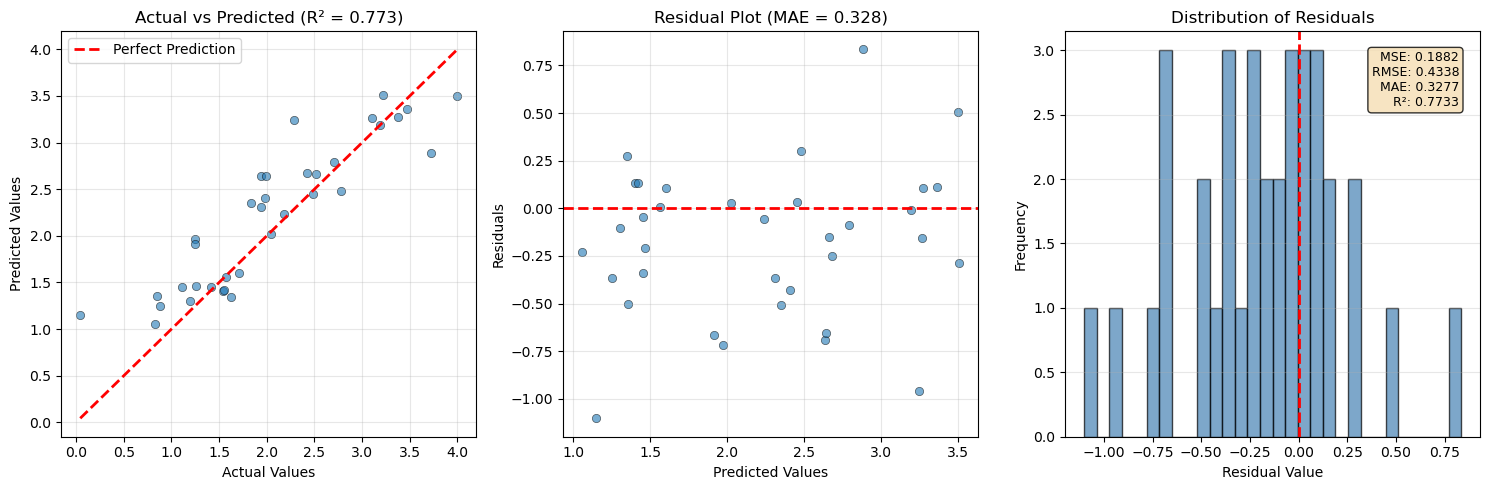

In [39]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.as_tensor(X_test, dtype=torch.float32, device=device)
    predictions = model(X_test_tensor).cpu().numpy()
    
    predictions = predictions.flatten()

    # Calculate metrics
    mse = mean_squared_error(Y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(Y_test, predictions)
    r2 = r2_score(Y_test, predictions)
    
    # Print metrics
    print(f"\n{'='*50}")
    print(f"{'='*50}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")
    
    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Plot 1: Actual vs Predicted
    axes[0].scatter(Y_test, predictions, alpha=0.6, edgecolors='k', linewidth=0.5)
    axes[0].plot([y_test.min(), Y_test.max()], [y_test.min(), Y_test.max()], 'r--', lw=2, label='Perfect Prediction')
    axes[0].set_xlabel('Actual Values')
    axes[0].set_ylabel('Predicted Values')
    axes[0].set_title(f'Actual vs Predicted (R² = {r2:.3f})')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Residuals
    residuals = Y_test - predictions
    print(residuals.shape, predictions.shape)
    axes[1].scatter(predictions, residuals, alpha=0.6, edgecolors='k', linewidth=0.5)
    axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[1].set_xlabel('Predicted Values')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title(f'Residual Plot (MAE = {mae:.3f})')
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Distribution of errors
    axes[2].hist(residuals, bins=30, alpha=0.7, edgecolor='black', color='steelblue')
    axes[2].axvline(x=0, color='r', linestyle='--', lw=2)
    axes[2].set_xlabel('Residual Value')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title('Distribution of Residuals')
    axes[2].grid(True, alpha=0.3, axis='y')
    
    # Add text box with metrics
    metrics_text = f'MSE: {mse:.4f}\nRMSE: {rmse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}'
    axes[2].text(0.95, 0.95, metrics_text, transform=axes[2].transAxes,
                fontsize=9, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()


# DENSE Model

### Load dense champion

In [48]:
from DENSE_model import *
from DENSE_functions import *

# Reshape data arrays for the dense
X_test_flat = X_test.reshape(X_test.shape[0], -1)
Y_test_flat = Y_test.reshape(Y_test.shape[0], -1)

x_test_prep   = torch.tensor(X_test_flat, dtype=torch.float32).to(device)
y_test_prep = torch.tensor(Y_test_flat, dtype=torch.float32).to(device).view(-1, 1)

input_size = x_test_prep.shape[1]

# Load champion dense model
dense_model_dir = "scoring_models/DENSE_models"
dense_model_path = os.path.join(dense_model_dir, "champion_model.pt")
dense_info_path = os.path.join(dense_model_dir, "champion_info.json")

# Load best state found during training
dense_state_dict = torch.load(dense_model_path, map_location=device)

with open(dense_info_path, "r") as f:
    dense_champion_info = json.load(f)

dense_champion_config = dense_champion_info["hyperparameters"]

print("DENSE CHAMPION CONFIGURATION")
print(dense_champion_config)

# Re-build champion model
dense_champion = build_dense_model(dense_champion_config, input_size)
dense_champion.load_state_dict(dense_state_dict)
dense_champion.to(device)

# Summarize dense champion model
model_summary = summary(dense_champion, input_size=(1, input_size), col_names=["input_size", "output_size", "num_params", "trainable"])

print("\nDENSE CHAMPION MODEL SUMMARY")
print(model_summary)

DENSE CHAMPION CONFIGURATION
{'layers': [256, 128, 64], 'lr': 0.0005, 'dropout': 0.1, 'activation': 'relu', 'epochs': 200}

DENSE CHAMPION MODEL SUMMARY
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
SquatRegDense                            [1, 1170]                 [1, 1]                    --                        True
├─Sequential: 1-1                        [1, 1170]                 [1, 1]                    --                        True
│    └─Linear: 2-1                       [1, 1170]                 [1, 256]                  299,776                   True
│    └─ReLU: 2-2                         [1, 256]                  [1, 256]                  --                        --
│    └─Dropout: 2-3                      [1, 256]                  [1, 256]                  --                        --
│    └─Linear: 2-4                       [1, 256]                  [1, 128]                  32,896   

## Evaluate dense model against test data

(35,) (35,)


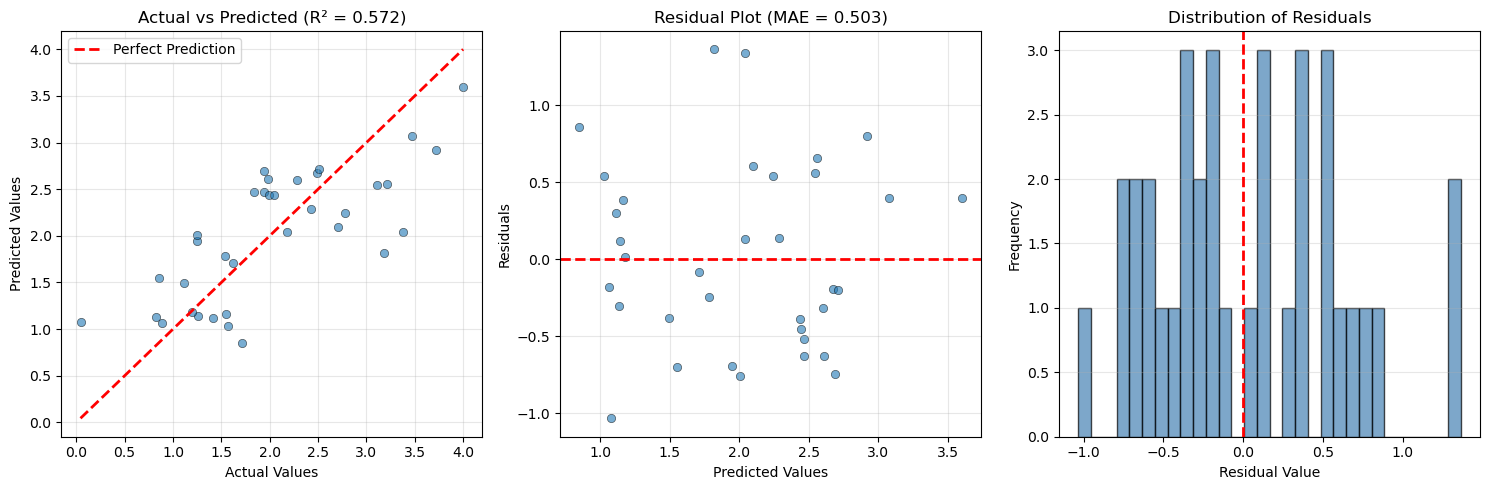


=== MODEL EVALUATION METRICS ===
MSE  : 0.3557
RMSE : 0.5964
MAE  : 0.5031
R²   : 0.5717



In [49]:
dense_champion.eval()
with torch.no_grad():
    predictions = dense_champion(x_test_prep)

    y_test_prep = y_test_prep.detach().cpu().numpy().ravel()
    predictions = predictions.detach().cpu().numpy().ravel()

    # Calculate metrics
    mse = mean_squared_error(y_test_prep, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_prep, predictions)
    r2 = r2_score(y_test_prep, predictions)
    
    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Plot 1: Actual vs Predicted
    axes[0].scatter(y_test_prep, predictions, alpha=0.6, edgecolors='k', linewidth=0.5)
    axes[0].plot([y_test_prep.min(), y_test_prep.max()], [y_test_prep.min(), y_test_prep.max()], 'r--', lw=2, label='Perfect Prediction')
    axes[0].set_xlabel('Actual Values')
    axes[0].set_ylabel('Predicted Values')
    axes[0].set_title(f'Actual vs Predicted (R² = {r2:.3f})')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)


    # Plot 2: Residuals
    residuals = y_test_prep - predictions
    print(residuals.shape, predictions.shape)
    axes[1].scatter(predictions, residuals, alpha=0.6, edgecolors='k', linewidth=0.5)
    axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[1].set_xlabel('Predicted Values')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title(f'Residual Plot (MAE = {mae:.3f})')
    axes[1].grid(True, alpha=0.3)

    # Plot 3: Distribution of errors
    axes[2].hist(residuals, bins=30, alpha=0.7, edgecolor='black', color='steelblue')
    axes[2].axvline(x=0, color='r', linestyle='--', lw=2)
    axes[2].set_xlabel('Residual Value')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title('Distribution of Residuals')
    axes[2].grid(True, alpha=0.3, axis='y')

    fig.tight_layout()
    plt.show()

print("\n=== MODEL EVALUATION METRICS ===")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")
print("===============================\n")